# Создание геометрических объектов

Для создания и работы с пространственными данными в Python существует библиотека `shapely` (https://shapely.readthedocs.io/en/stable/index.html).

> **NB** эта библиотека умеет работать только на плоскости

Каждый объект состоит из *внутреннего, внешнего и граничного* множеств (interior, boundary, and exterior sets of a feature), которые являются взаимоисключающими.

Основные типы объектов, реализованные в библиотеке:

1. **Point** (точка) - объект с нулевой размерностью, для которого внутреннее множество будет состоять из одной точки, граница - из нулевого количества точек, а внешнее множество представляет собой набор всех остальных возможных точек. Такие объекты относятся к классу `Point`.

2. **Curve** (кривая) - объект с размерностью 1, для которого внутреннее множество будет состоять из бесконечного количества точек вдоль линии, граница - из двух точек (начальной и конечной), а внешнее множество представляет собой набор всех остальных возможных точек. Такие объекты относятся к классам `Linestring` (разомкнутая кривая) и `LinearRing` (замкнутая кривая).

3. **Surface** (поверхность) - объект с размерностью 2, для которого внутреннее множество будет состоять из бесконечного множества точек, расположенных внутри, граница - из одной или нескольких кривых, а внешнее множество представляет собой набор всех остальных возможных точек, включая те, которые могут находиться в отверстиях поверхности. Такие объекты относятся к классу `Polygon`.


В библиотеке `shapely` наиболее применяемыми способами создания объектов являются:
- создание объектов из списка координат;
- создание объектов из словаря (dictionary `dict` [немного о словарях](https://pythonworld.ru/tipy-dannyx-v-python/slovari-dict-funkcii-i-metody-slovarej.html)), в данном случае фактически словари создаются на основе формата описания географических данных `geojson`;
- создание объектов из строки, то есть на основе описания в формате `wkt`

Установка библиотеки

In [ ]:
# pip install shapely

## Создание объектов из списка координат

### Точки

In [48]:
from shapely.geometry import Point

Создадим точку из списка координат. Для этого нам достаточно всего одной пары координат.

In [2]:
pin_itmo = Point ([59.944295,30.265266])

Проверим тип полученного объекта.

In [3]:
print(f"Тип объекта: {type(pin_itmo)}")

Тип объекта: <class 'shapely.geometry.point.Point'>


Кроме того, с помощью одного из [методов, реализованных в пакете для классов](https://shapely.readthedocs.io/en/stable/manual.html#general-attributes-and-methods), можно проверить тип геометрии объекта.


In [4]:
print(f"Тип геометрии объекта: {pin_itmo.geom_type}")

Тип геометрии объекта: Point


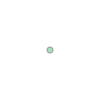

In [5]:
pin_itmo

### Линии

In [6]:
from shapely.geometry import LineString

Так как линия состоит из множества точек, а границей являются начальная и конечная точки линии, то для ее создания нужно как минимум две пары координат, заданных в виде [кортежа](https://younglinux.info/python/tuple) (`tuple`).

> Линия создается в том порядке, в котором координаты точек перечисляются в кортеже

In [7]:
pointsList = [[59.929624, 30.268675], [59.936355, 30.257589]]
line = LineString (pointsList)

In [8]:
print(f"Тип объекта: {type(line)}")

Тип объекта: <class 'shapely.geometry.linestring.LineString'>


In [9]:
print(f"Тип геометрии объекта: {line.geom_type}")

Тип геометрии объекта: LineString


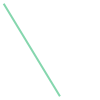

In [10]:
line

Если нужно создать ломаную линию, то просто в список нужно внести не только координаты начальной и конечной точки, но и всех промежуточных поворотных точек.

> Линия может пересекать сама себя. 
Линия без самопересечений является простой (*simple*), а с самопересечениями - комплексной (*complex*).

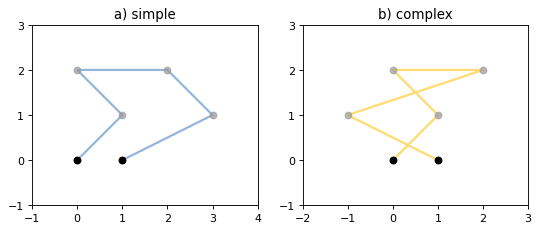

In [8]:
pointsList1 = [[59.929624, 30.268675], [59.936355, 30.257589], 
               [59.944295,30.265266], [59.943311, 30.268789]]
line1 = LineString (pointsList1)

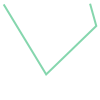

In [9]:
line1

Кроме того, линия может быть создана из нескольких точек или кортежа с парами координат.

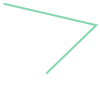

In [10]:
LineString([Point(59.929624, 30.268675), pin_itmo, (59.936355, 30.257589)])

Линии также могут быть замкнутыми. Для их создания используется класс `LinearRing`.

Главное отличие в создании между `LineString` и `LinearRing` в том, что для второго класса обязательно нужно в конце повторить координаты первой точки.

> Замкнутые линии не могут пересекать сами себя и касаться самих себя

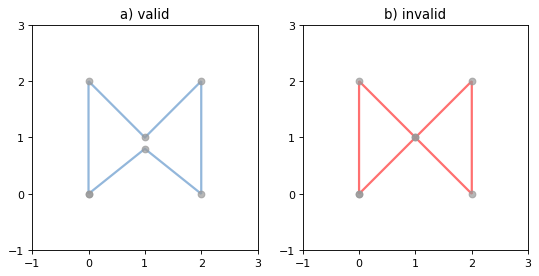

> Важно помнить, что это все еще линия, то есть у нее нулевая площадь и ненулевая длина.

In [16]:
from shapely.geometry import LinearRing

In [17]:
pointsList2 = [[59.929624, 30.268675], [59.936355, 30.257589], 
               [59.944295,30.265266], [59.943311, 30.268789],
               [59.929624, 30.268675]]
line2 = LinearRing(pointsList2)

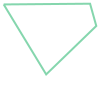

In [18]:
line2

Однако для проверки валидности геометрии объекта, можно модифицировать его таким образом, чтобы при появлении самопересечений выдавалось предупреждение об этом.

In [23]:
class LinearRing_2(LinearRing):
    
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        if not self.is_valid:
            raise ValueError("Самопересечение")

In [28]:
pointsList2 = [[59.929624, 30.268675], [59.943311, 30.268789], [59.936355, 30.257589], 
               [59.944295,30.265266],
               [59.929624, 30.268675]]
line2 = LinearRing_2(pointsList2)

ValueError: Самопересечение

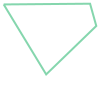

In [27]:
line2

### Полигоны

In [29]:
from shapely.geometry import Polygon

При создании полигонов в качестве параметров сначала подается список или кортеж с координатами, а потом неупорядоченная последовательность кольцевых последовательностей, определяющих внутренние границы или "отверстия" объекта.

> Отверстия внутри полигона могут касаться его внешних границ только в одной точке, не могут иметь между собой общие границы и не могут пересекаться.
> Такие случаи приводят к созданию некорректных полигонов.

> **!** `shapely` не предотвращает создание некорректных объектов, но дальнейшие операции с ними могут быть невозможны.

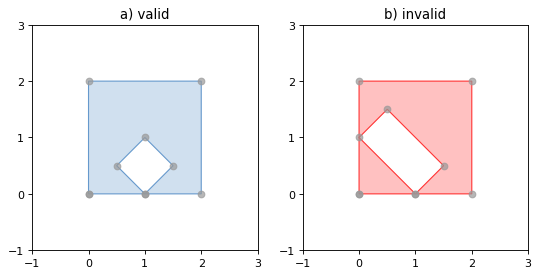

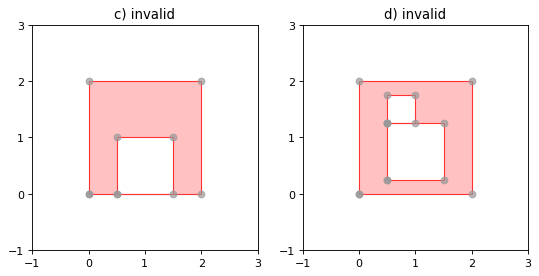

In [30]:
pointList = [[59.928813,30.268443], [59.931574,30.268144], [59.929816,30.270000]]

poly_mining = Polygon(pointList)

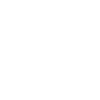

In [31]:
poly_mining

In [32]:
print(f"Тип объекта: {type(poly_mining)}")

Тип объекта: <class 'shapely.geometry.polygon.Polygon'>


In [33]:
print(f"Тип геометрии объекта: {poly_mining.geom_type}")

Тип геометрии объекта: Polygon


Получим список координат границы полигона.

Координаты внешнего контура можно получить через `exterior` свойства, а координаты внутренних контуров через `interior`.

In [34]:
list(poly_mining.exterior.coords)

[(59.928813, 30.268443),
 (59.931574, 30.268144),
 (59.929816, 30.27),
 (59.928813, 30.268443)]

Обратите внимание, что в полученном полигоне координаты первой точки повторяются еще и в конце. Таким образом достигается замкнутость полигона.

In [35]:
print(f'Длина исходного списка координат: {len(list(pointList))},'\
      f' длина списка координат объекта shapely: {len(list(poly_mining.exterior.coords))}'
      )

Длина исходного списка координат: 3, длина списка координат объекта shapely: 4


## Создание объектов из словаря

При создании словаря, который будет конвертироваться в пространственный объект, фактически используется `geojson`, который является универсальным форматом данных, не привязанным к конкретному языку программирования. 

Этот формат основан на JavaScript object notation (JSON).

В GeoJSON объект состоит из набора пар ключ/значение, также называемых свойствами. Имя каждого свойства – строка. Значение свойства может представлять собой строку, число, объект, массив или один из литералов: «true», «false» и «null». 
Подробнее о формате можно почитать [здесь](https://geojson.org/)

### Точки

При создании точки из словаря, в нем обязательно должны быть два основных свойства:
- "type" - тип геометрии объекта;
- "coordinates" - перечень координат в виде списков или кортежей.

In [36]:
from shapely.geometry import shape

In [37]:
pin_itmo_geojson = {"type":"Point",
                   "coordinates":[59.944295,30.265266]
                   }

In [38]:
print(f"Текущий тип объекта: {type(pin_itmo_geojson)}")

Текущий тип объекта: <class 'dict'>


In [39]:
pin_itmo1 = shape(pin_itmo_geojson)

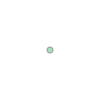

In [40]:
pin_itmo1

In [41]:
print(f"Текущий тип объекта: {type(pin_itmo1)}")

Текущий тип объекта: <class 'shapely.geometry.point.Point'>


### Линии

In [42]:
line_geojson = {"type":"Linestring",
                "coordinates": [[59.929624, 30.268675],
                                [59.936355, 30.257589]],
                }

line3 = shape(line_geojson)

In [44]:
print(f"Текущий тип объекта: {type(line3)}")

Текущий тип объекта: <class 'shapely.geometry.linestring.LineString'>


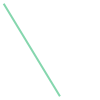

In [45]:
line3

### Полигоны

In [46]:
poly_mining_geojson ={"type":"Polygon",
                      "coordinates": [[[59.928795, 30.268423],
                                       [59.930972, 30.265923],
                                       [59.931569, 30.268101],
                                       [59.929806, 30.269936],
                                       [59.928795, 30.268423]]],
                       }

poly_mining2 = shape(poly_mining_geojson)

In [47]:
print(f"Текущий тип объекта: {type(poly_mining2)}")

Текущий тип объекта: <class 'shapely.geometry.polygon.Polygon'>


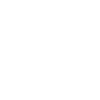

In [48]:
poly_mining2

## Создание объектов из текстовой строки

В этом случае описание объектов должно строиться на основе формата [WKT](https://ru.wikipedia.org/wiki/WKT) 

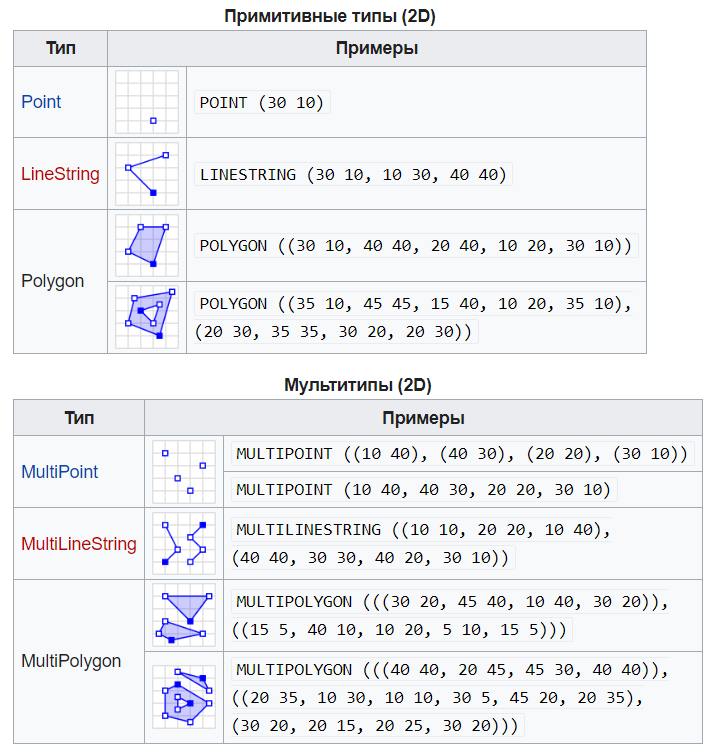

In [50]:
from shapely import wkt

Для того, чтобы строка в формате WKT была преобразована в геометрический пространственный объект нужно воспользоваться функцией `wkt.loads` (load string). 

### Точки

In [51]:
pin_itmo2 = wkt.loads('POINT (59.944295 30.265266)')

print(f"Тип объекта: {type(pin_itmo2)}")

Тип объекта: <class 'shapely.geometry.point.Point'>


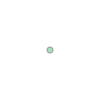

In [52]:
pin_itmo2

### Линии

In [53]:
line_wkt = 'LINESTRING (59.929624 30.268675, 59.936355 30.257589)'

line4 = wkt.loads(line_wkt)

In [54]:
print(f"Тип объекта: {type(line4)}")

Тип объекта: <class 'shapely.geometry.linestring.LineString'>


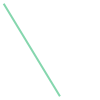

In [55]:
line4

### Полигоны

In [58]:
poly_mining_str = """POLYGON ((59.928795 30.268423, 59.930972 30.265923, 59.931569 30.268101, 
                     59.929806 30.269936, 59.928795 30.268423))"""

poly_mining4 = wkt.loads(poly_mining_str)

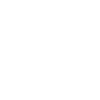

In [59]:
poly_mining4

In [60]:
print(f"Тип объекта: {type(poly_mining4)}")

Тип объекта: <class 'shapely.geometry.polygon.Polygon'>


Обратите внимание, что при создании полигонов таким способом в строке с перечнем координат координаты первой точки должны обязательно также повторяться в конце.

## Основные свойства объектов

- `object.area` - возвращает площадь объектов в виде числа `float` (у точечных и линейных объектов будет нулевой)

In [61]:
pin_itmo.area

0.0

In [62]:
line.area

0.0

In [63]:
poly_mining.area

2.299386999998814e-06

- `object.length` - возвращает длину объектов в виде числа `float` (у точечных объектов будет нулевой, для линейных объектов будет равна длине линии, а для площадных объектов - периметру)

In [64]:
pin_itmo.length

0.0

In [65]:
line.length

0.012969416216625946

In [53]:
poly_mining.length

0.007185661628829153

- `object.bounds` - возвращает кортеж координат (minx, miny, maxx, maxy) из числовых значений; полученные границы полностью охватывают объект

In [66]:
pin_itmo.bounds

(59.944295, 30.265266, 59.944295, 30.265266)

In [67]:
line.bounds

(59.929624, 30.257589, 59.936355, 30.268675)

In [69]:
poly_mining.bounds

(59.928813, 30.268144, 59.931574, 30.27)

## Геометрические предикаты

Все геометрические предикаты возвращают только **True** или **False**.

### Унарные предикаты

Это атрибуты объектов.
При их использовании задействуется только один объект.

- `object.is_empty` - возвращает **True**, если объект является пустым набором

In [57]:
pin_itmo.is_empty

False

In [58]:
Point().is_empty

True

- `object.is_ring` - проверяет является ли объект замкнутой ломаной линией; имеет значение только для `LineString` и `LinearRing` объектов

In [59]:
line1.is_ring

False

In [60]:
line2.is_ring

True

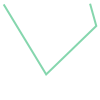

In [61]:
line1

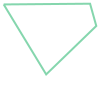

In [62]:
line2

- `object.is_simple` - возвращает **True**, если объект не пересекает сам себя; имеет значение только для `LineString` и `LinearRing` объектов

In [63]:
line1.is_simple

True

In [64]:
line2.is_simple

True

- `object.is_valid` - возвращает **True**, если объект не имеет топологических ошибок; имеет значение только для `Polygon` и `MultiPolygon` объектов, для всех остальных объектов всегда возвращает **True**

In [65]:
poly_mining.is_valid

True

### Бинарные предикаты

Эти предикаты реализованы как методы классов.
Они исследуют наличие топологических, теоретико-множественных отношений.

- `object.equals(other)` - возвращает **True**, если граничное, внешнее и внутренее множества двух объектов совпадают.

In [66]:
poly_mining.equals(poly_mining2)

False

In [67]:
poly_mining2.equals(poly_mining4)

True

- `object.contains(other)` - возвращает **True**, если ни одна из точек второго объекта (other) не находится в наружном множества объекта и как минимум одна точка внутреннего множества второго объекта попадает во внутренее множество объекта

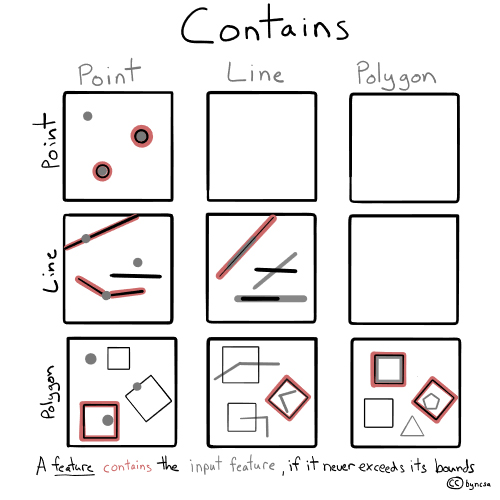

In [68]:
poly_mining.contains(pin_itmo)

False

In [69]:
line1.contains(pin_itmo)

True

- `object.covers(other)` - возвращает **True**, если каждая точка второго объекта находится во внутреннем или граничном множестве объекта; отличается от предыдущего метода тем, что не требует нахождения точек из внутренного множества второго объекта во внутреннем множестве первого

- `object.covered_by(other)` - возвращает **True**, если каждая точка объекта является точкой внутреннего или граничного множества второго объекта; фактически противоположна предыдущему методу

- `object.crosses(other)` - возвращает **True**, если внутреннее множество объекта пересекает внутреннее множество второго объекта, но не содержит его; размерность пересечения меньше размерности любого из объектов (например, пересечение полигонов, размерность которых 2, - это линия с размерностью 1); линия не может пересекать точку, которую содержит

- `object.intersects(other)` - возвращает **True**, если граничное или внутреннее множество пересекает аналогичные множества второго объекта, то есть объекты пересекаются, если у них есть общая точка на границе или во внутреннем множестве

- `object.overlaps(other)` - возвращает **True**, если у объектов более одной общей точки, но не все, они имеют одинаковую размерность и размерность пересечения такая же, как размерность исходных объектов

- `object.touches(other)` - возвращает **True**, если у объектов есть хотя бы одна общая точка, но их внутренние множества не пересекаются

- `object.within(other)` - возвращает **True**, если граничное или внутреннее множество объекта пересекается с внутренним множеством второго объекта, но не граничным или внешним множеством

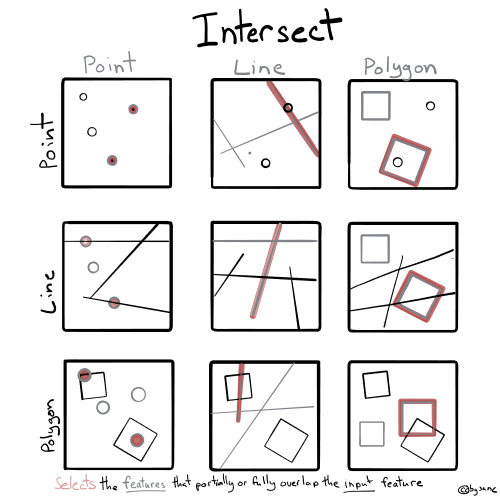

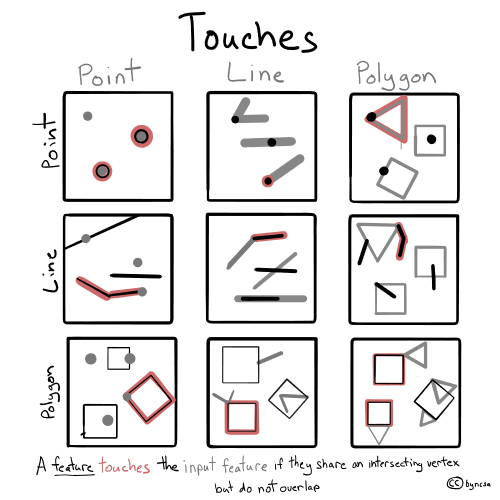

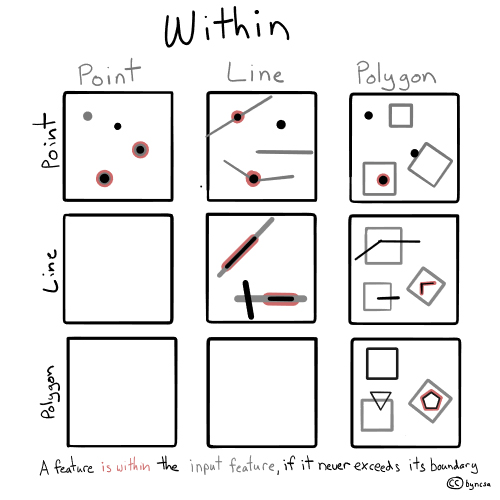

# GeoPandas и геодатафреймы

`GeoPandas` расширяет  библиотеку данных `pandas`, добавляя поддержку геопространственных данных (https://geopandas.org/en/stable/index.html).

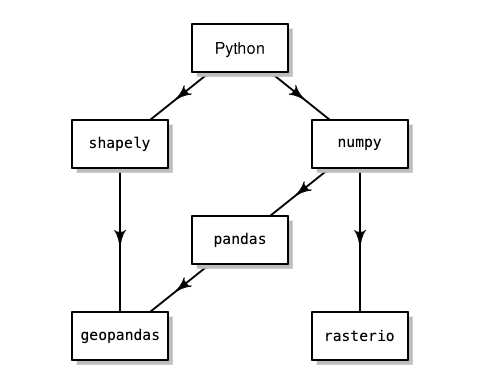

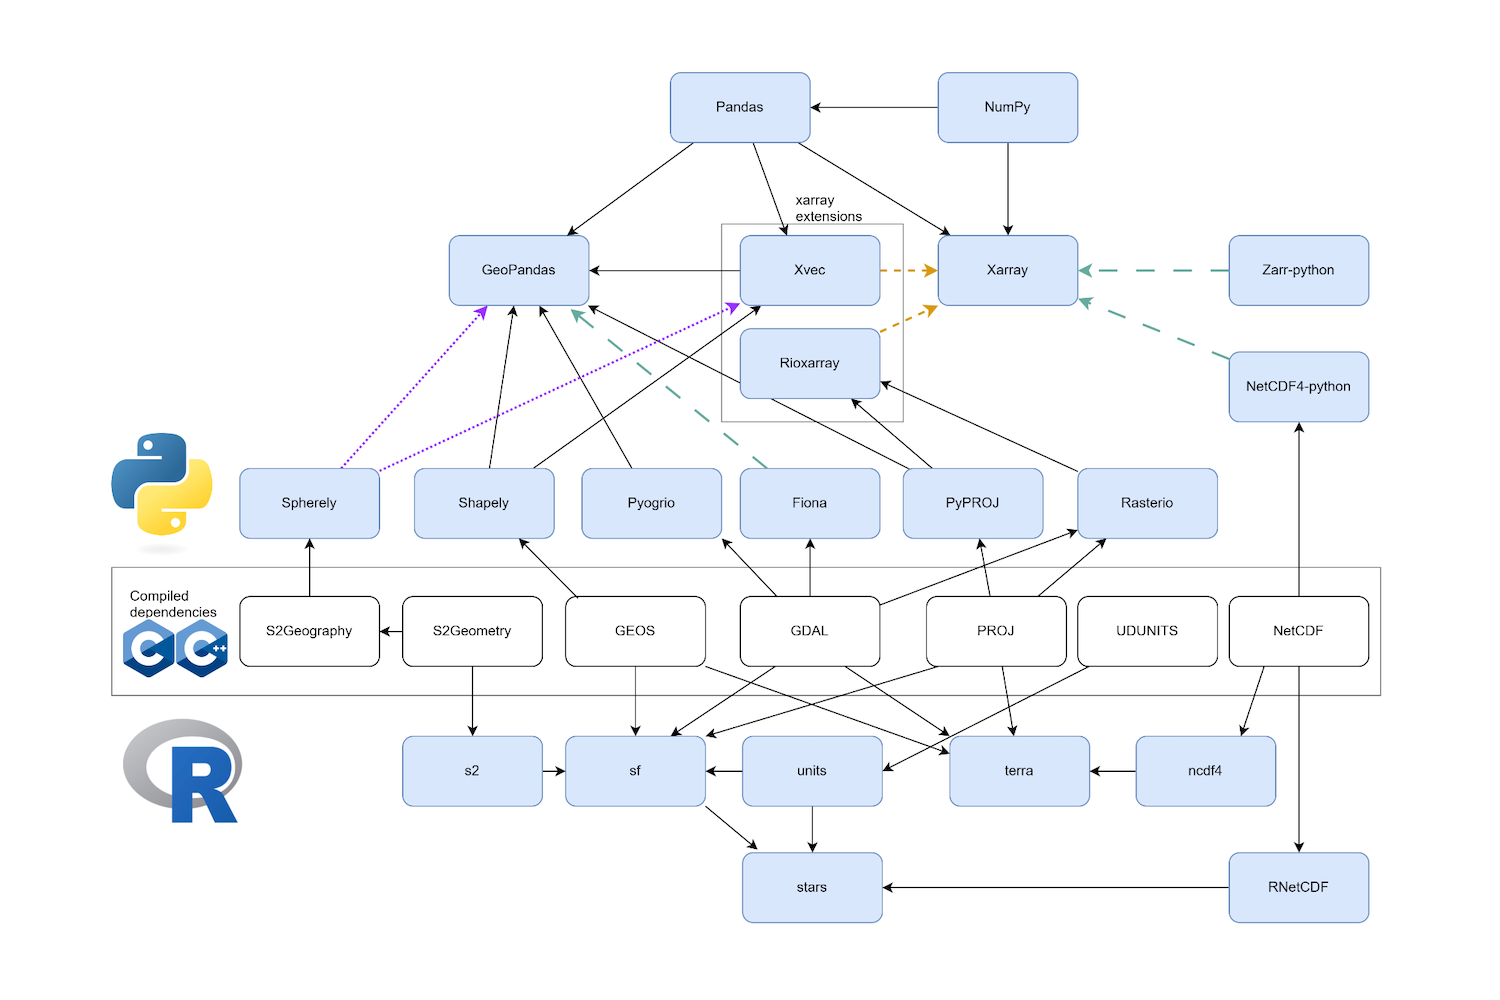

Основной структурой данных в GeoPandas является `geopandas.GeoDataFrame`, подкласс `pandas.DataFrame`, который может хранить геометрические столбцы и выполнять пространственные операции. 

`Geopandas.GeoSeries`, подкласс `pandas.Series`, обрабатывает геометрические данные. Таким образом, ваш `GeoDataFrame` - это комбинация `pandas.Series` с традиционными данными (числовыми, булевыми, текстовыми и т.д.) и `geopandas.GeoSeries` с геометрией (точками, полигонами и т.д.). Вы можете иметь столько столбцов с геометриями, сколько пожелаете; нет ограничений, характерных для настольных ГИС-программ.

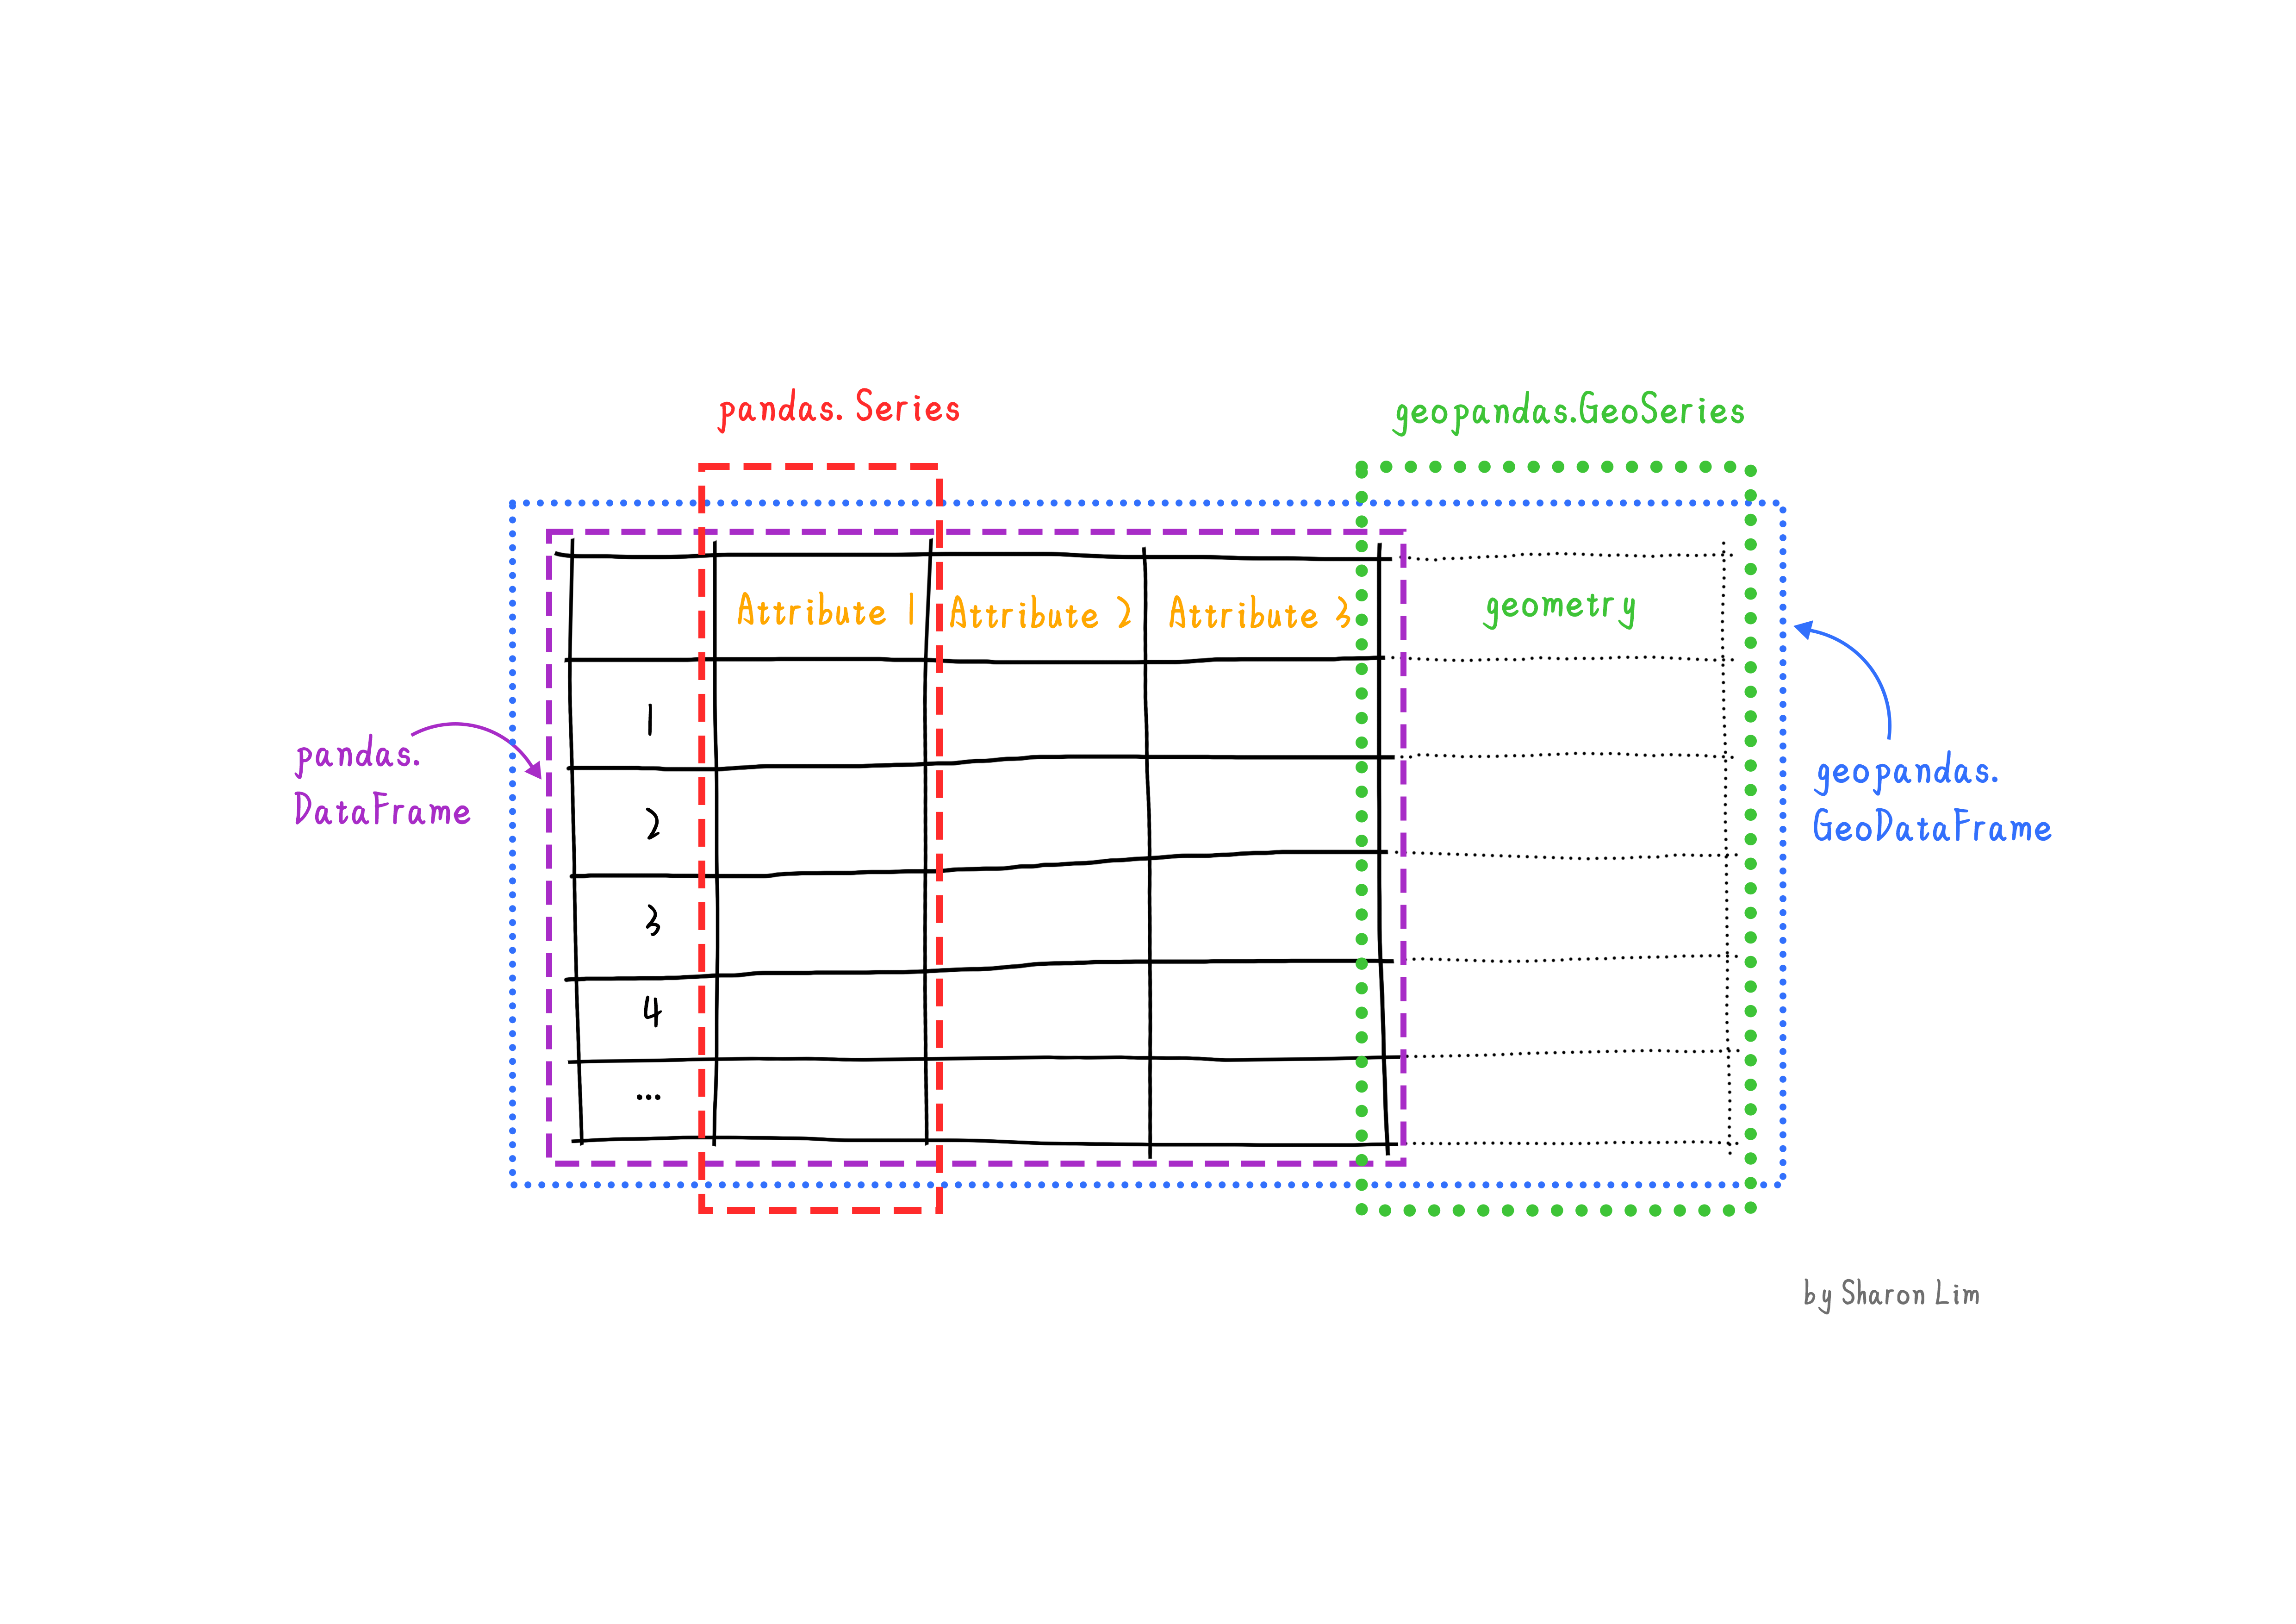

То есть фактически `Geoseries` - это геометрии объектов, а `GeoDataFrame` - аналог векторного слоя в ГИС.

Каждая `Geoseries` может содержать любой тип геометрии (вы можете даже смешивать их в одном массиве) и имеет атрибут `GeoSeries.crs`, который хранит информацию о системе координат (CRS означает Coordinate Reference System). Таким образом, каждая `GeoSeries` в `GeoDataFrame` может быть в разной проекции, что позволяет иметь, например, несколько версий (разных проекций) одной и той же геометрии.

Только одна GeoSeries в `GeoDataFrame` считается активной геометрией, что означает, что все геометрические операции, применяемые к GeoDataFrame, работают с этим активным столбцом.

In [1]:
 pip install geopandas


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
 pip install geodatasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [geodatasets]

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import geopandas as gpd
import geodatasets

Функция `gpd.read_file` позволяет читать основные типы векторных файлов, используемых в ГИС.
- Shapefile (.shp)

- GeoJSON (.geojson)

- GeoPackage (.gpkg)

- File Geodatabase (.gdb)

In [7]:
guerry = gpd.read_file(geodatasets.get_path("geoda.guerry"))

Extracting 'guerry/guerry.shp' from '/Users/tatianabaltyzhakova/Library/Caches/geodatasets/guerry.zip' to '/Users/tatianabaltyzhakova/Library/Caches/geodatasets/guerry.zip.unzip'
Extracting 'guerry/guerry.dbf' from '/Users/tatianabaltyzhakova/Library/Caches/geodatasets/guerry.zip' to '/Users/tatianabaltyzhakova/Library/Caches/geodatasets/guerry.zip.unzip'
Extracting 'guerry/guerry.shx' from '/Users/tatianabaltyzhakova/Library/Caches/geodatasets/guerry.zip' to '/Users/tatianabaltyzhakova/Library/Caches/geodatasets/guerry.zip.unzip'
Extracting 'guerry/guerry.prj' from '/Users/tatianabaltyzhakova/Library/Caches/geodatasets/guerry.zip' to '/Users/tatianabaltyzhakova/Library/Caches/geodatasets/guerry.zip.unzip'


In [8]:
type(guerry)

geopandas.geodataframe.GeoDataFrame

<Axes: >

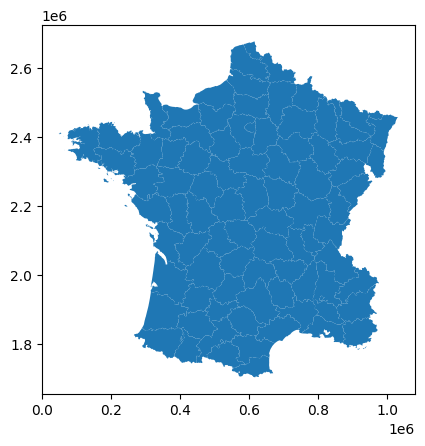

In [9]:
guerry.plot()

In [10]:
guerry.head()

,dept,Region,Dprtmnt,Crm_prs,Crm_prp,Litercy,Donatns,Infants,Suicids,MainCty,...,Infntcd,Dntn_cl,Lottery,Desertn,Instrct,Prsttts,Distanc,Area,Pop1831,geometry
0,1.0,E,Ain,28870.0,15890.0,37.0,5098.0,33120.0,35039.0,2.0,...,60.0,69.0,41.0,55.0,46.0,13.0,218.372,5762.0,346.03,"POLYGON ((801150 2092615, 800669 2093190, 8006..."
1,2.0,N,Aisne,26226.0,5521.0,51.0,8901.0,14572.0,12831.0,2.0,...,82.0,36.0,38.0,82.0,24.0,327.0,65.945,7369.0,513.00,"POLYGON ((729326 2521619, 729320 2521230, 7292..."
2,3.0,C,Allier,26747.0,7925.0,13.0,10973.0,17044.0,114121.0,2.0,...,42.0,76.0,66.0,16.0,85.0,34.0,161.927,7340.0,298.26,"POLYGON ((710830 2137350, 711746 2136617, 7124..."
3,4.0,E,Basses-Alpes,12935.0,7289.0,46.0,2733.0,23018.0,14238.0,1.0,...,12.0,37.0,80.0,32.0,29.0,2.0,351.399,6925.0,155.90,"POLYGON ((882701 1920024, 882408 1920733, 8817..."
4,5.0,E,Hautes-Alpes,17488.0,8174.0,69.0,6962.0,23076.0,16171.0,1.0,...,23.0,64.0,79.0,35.0,7.0,1.0,320.280,5549.0,129.10,"POLYGON ((886504 1922890, 885733 1922978, 8854..."


In [11]:
guerry

,dept,Region,Dprtmnt,Crm_prs,Crm_prp,Litercy,Donatns,Infants,Suicids,MainCty,...,Infntcd,Dntn_cl,Lottery,Desertn,Instrct,Prsttts,Distanc,Area,Pop1831,geometry
0,1.0,E,Ain,28870.0,15890.0,37.0,5098.0,33120.0,35039.0,2.0,...,60.0,69.0,41.0,55.0,46.0,13.0,218.372,5762.0,346.03,"POLYGON ((801150 2092615, 800669 2093190, 8006..."
1,2.0,N,Aisne,26226.0,5521.0,51.0,8901.0,14572.0,12831.0,2.0,...,82.0,36.0,38.0,82.0,24.0,327.0,65.945,7369.0,513.00,"POLYGON ((729326 2521619, 729320 2521230, 7292..."
2,3.0,C,Allier,26747.0,7925.0,13.0,10973.0,17044.0,114121.0,2.0,...,42.0,76.0,66.0,16.0,85.0,34.0,161.927,7340.0,298.26,"POLYGON ((710830 2137350, 711746 2136617, 7124..."
3,4.0,E,Basses-Alpes,12935.0,7289.0,46.0,2733.0,23018.0,14238.0,1.0,...,12.0,37.0,80.0,32.0,29.0,2.0,351.399,6925.0,155.90,"POLYGON ((882701 1920024, 882408 1920733, 8817..."
4,5.0,E,Hautes-Alpes,17488.0,8174.0,69.0,6962.0,23076.0,16171.0,1.0,...,23.0,64.0,79.0,35.0,7.0,1.0,320.280,5549.0,129.10,"POLYGON ((886504 1922890, 885733 1922978, 8854..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,85.0,W,Vendee,20827.0,7566.0,28.0,14035.0,62486.0,67963.0,1.0,...,44.0,30.0,68.0,79.0,59.0,4.0,212.459,6720.0,330.36,"MULTIPOLYGON (((243055 2197885, 243019 2198089..."
81,86.0,W,Vienne,15010.0,4710.0,25.0,8922.0,35224.0,21851.0,2.0,...,1.0,44.0,40.0,38.0,65.0,18.0,170.523,6990.0,282.73,"POLYGON ((450395 2119945, 450065 2120124, 4494..."
82,87.0,C,Haute-Vienne,16256.0,6402.0,13.0,13817.0,19940.0,33497.0,2.0,...,6.0,78.0,55.0,11.0,84.0,7.0,198.874,5520.0,285.13,"POLYGON ((515230 2049895, 514990 2049594, 5143..."
83,88.0,E,Vosges,18835.0,9044.0,62.0,4040.0,14978.0,33029.0,2.0,...,34.0,5.0,14.0,85.0,11.0,43.0,174.477,5874.0,397.99,"POLYGON ((951144 2383215, 953082 2382491, 9534..."


Для того, чтобы посмотреть `GeoDataFrame` целиком, нужно установить большее значение в максимальном количестве строк, которое отображается при вызове объекта.

In [12]:
import pandas as pd

In [13]:
pd.set_option("display.max_rows", 100)

In [14]:
guerry

,dept,Region,Dprtmnt,Crm_prs,Crm_prp,Litercy,Donatns,Infants,Suicids,MainCty,...,Infntcd,Dntn_cl,Lottery,Desertn,Instrct,Prsttts,Distanc,Area,Pop1831,geometry
0,1.0,E,Ain,28870.0,15890.0,37.0,5098.0,33120.0,35039.0,2.0,...,60.0,69.0,41.0,55.0,46.0,13.0,218.372,5762.0,346.03,"POLYGON ((801150 2092615, 800669 2093190, 8006..."
1,2.0,N,Aisne,26226.0,5521.0,51.0,8901.0,14572.0,12831.0,2.0,...,82.0,36.0,38.0,82.0,24.0,327.0,65.945,7369.0,513.00,"POLYGON ((729326 2521619, 729320 2521230, 7292..."
2,3.0,C,Allier,26747.0,7925.0,13.0,10973.0,17044.0,114121.0,2.0,...,42.0,76.0,66.0,16.0,85.0,34.0,161.927,7340.0,298.26,"POLYGON ((710830 2137350, 711746 2136617, 7124..."
3,4.0,E,Basses-Alpes,12935.0,7289.0,46.0,2733.0,23018.0,14238.0,1.0,...,12.0,37.0,80.0,32.0,29.0,2.0,351.399,6925.0,155.90,"POLYGON ((882701 1920024, 882408 1920733, 8817..."
4,5.0,E,Hautes-Alpes,17488.0,8174.0,69.0,6962.0,23076.0,16171.0,1.0,...,23.0,64.0,79.0,35.0,7.0,1.0,320.280,5549.0,129.10,"POLYGON ((886504 1922890, 885733 1922978, 8854..."
5,7.0,S,Ardeche,9474.0,10263.0,27.0,3188.0,42117.0,52547.0,1.0,...,47.0,67.0,70.0,19.0,62.0,1.0,279.413,5529.0,340.73,"POLYGON ((747008 1925789, 746630 1925762, 7457..."
6,8.0,N,Ardennes,35203.0,8847.0,67.0,6400.0,16106.0,26198.0,2.0,...,85.0,49.0,31.0,62.0,9.0,83.0,105.694,5229.0,289.62,"POLYGON ((818893 2514767, 818614 2514515, 8179..."
7,9.0,S,Ariege,6173.0,9597.0,18.0,3542.0,22916.0,123625.0,1.0,...,28.0,63.0,75.0,22.0,77.0,3.0,385.313,4890.0,253.12,"POLYGON ((509103 1747787, 508820 1747513, 5081..."
8,10.0,E,Aube,19602.0,4086.0,59.0,3608.0,18642.0,10989.0,2.0,...,54.0,9.0,28.0,86.0,15.0,207.0,83.244,6004.0,246.36,"POLYGON ((775400 2345600, 775068 2345397, 7735..."
9,11.0,S,Aude,15647.0,10431.0,34.0,2582.0,20225.0,66498.0,2.0,...,35.0,27.0,50.0,63.0,48.0,1.0,370.949,6139.0,270.13,"POLYGON ((626230 1810121, 626269 1810496, 6274..."


<Axes: >

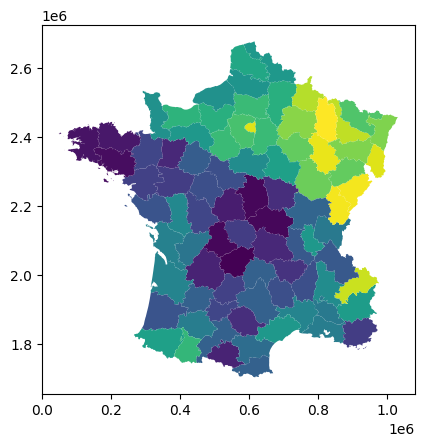

In [15]:
guerry.plot(column = 'Litercy')

<Axes: >

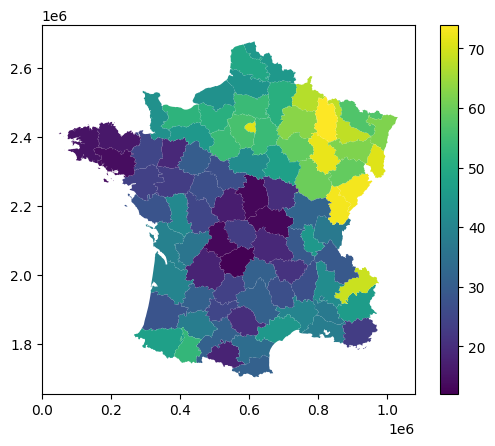

In [16]:
guerry.plot(column = 'Litercy', legend = True)

Геометрии объектов являются объектами библиотеки `shapely`

In [17]:
guerry.geometry

0     POLYGON ((801150 2092615, 800669 2093190, 8006...
1     POLYGON ((729326 2521619, 729320 2521230, 7292...
2     POLYGON ((710830 2137350, 711746 2136617, 7124...
3     POLYGON ((882701 1920024, 882408 1920733, 8817...
4     POLYGON ((886504 1922890, 885733 1922978, 8854...
5     POLYGON ((747008 1925789, 746630 1925762, 7457...
6     POLYGON ((818893 2514767, 818614 2514515, 8179...
7     POLYGON ((509103 1747787, 508820 1747513, 5081...
8     POLYGON ((775400 2345600, 775068 2345397, 7735...
9     POLYGON ((626230 1810121, 626269 1810496, 6274...
10    POLYGON ((642972 1978185, 643791 1976549, 6444...
11    POLYGON ((824692 1865875, 825615 1865409, 8259...
12    POLYGON ((345476 2429914, 345299 2430235, 3436...
13    POLYGON ((591653 2017934, 591727 2018244, 5918...
14    POLYGON ((456425 2120055, 456229 2120382, 4559...
15    MULTIPOLYGON (((328075 2118055, 327916 2118168...
16    POLYGON ((572720 2252955, 574278 2251834, 5753...
17    POLYGON ((608225 2042680, 608101 2042880, 

In [18]:
guerry['geometry']

0     POLYGON ((801150 2092615, 800669 2093190, 8006...
1     POLYGON ((729326 2521619, 729320 2521230, 7292...
2     POLYGON ((710830 2137350, 711746 2136617, 7124...
3     POLYGON ((882701 1920024, 882408 1920733, 8817...
4     POLYGON ((886504 1922890, 885733 1922978, 8854...
5     POLYGON ((747008 1925789, 746630 1925762, 7457...
6     POLYGON ((818893 2514767, 818614 2514515, 8179...
7     POLYGON ((509103 1747787, 508820 1747513, 5081...
8     POLYGON ((775400 2345600, 775068 2345397, 7735...
9     POLYGON ((626230 1810121, 626269 1810496, 6274...
10    POLYGON ((642972 1978185, 643791 1976549, 6444...
11    POLYGON ((824692 1865875, 825615 1865409, 8259...
12    POLYGON ((345476 2429914, 345299 2430235, 3436...
13    POLYGON ((591653 2017934, 591727 2018244, 5918...
14    POLYGON ((456425 2120055, 456229 2120382, 4559...
15    MULTIPOLYGON (((328075 2118055, 327916 2118168...
16    POLYGON ((572720 2252955, 574278 2251834, 5753...
17    POLYGON ((608225 2042680, 608101 2042880, 

Фактически колонка `geometry` представляет собой объект `GeoSeries`.
Именно эта колонка то, что отличает `GeoDataFrame` от `DataFrame`

In [19]:
type(guerry['geometry'])

geopandas.geoseries.GeoSeries

Так как в нашем `GeoDataFrame` хранится целый набор объектов, мы можем обращаться к каждому из них отдельно

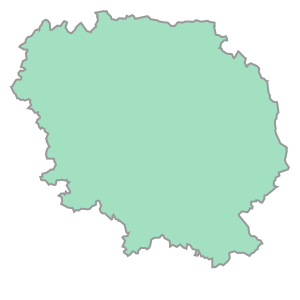

In [20]:
guerry['geometry'].iloc[20]

Кроме того, что у объектов есть геометрия, у них еще есть и система координат CRS (coordinate reference system) описанная в соответствии с реестром **EPSG**.
Про системы координат и их преобразования будет чуть ниже.

In [21]:
guerry.crs

<Projected CRS: EPSG:27572>
Name: NTF (Paris) / Lambert zone II
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: France mainland onshore between 50.5 grads and 53.5 grads North (45°27'N to 48°09'N). Also used over all onshore mainland France.
- bounds: (-4.87, 42.33, 8.23, 51.14)
Coordinate Operation:
- name: Lambert zone II
- method: Lambert Conic Conformal (1SP)
Datum: Nouvelle Triangulation Francaise (Paris)
- Ellipsoid: Clarke 1880 (IGN)
- Prime Meridian: Paris

Так как каждый пространственный объект занимает определенную часть поверхности, мы можем знать охват каждого элемента `GeoDataFrame`.

In [22]:
guerry.bounds

,minx,miny,maxx,maxy
0,785562.0,2073221.0,894622.0,2172530.0
1,645357.0,2427270.0,738049.0,2564568.0
2,595532.0,2104320.0,728480.0,2200625.0
3,853311.0,1858801.0,970310.0,1972682.0
4,845528.0,1915176.0,975716.0,2022608.0
5,720908.0,1920016.0,801330.0,2043510.0
6,722230.0,2472836.0,821101.0,2577475.0
7,476458.0,1729992.0,586665.0,1813083.0
8,677472.0,2326409.0,787769.0,2414830.0
9,547293.0,1738382.0,673587.0,1828670.0


Или охват всего `GeoDataFrame`

In [23]:
guerry.total_bounds

array([  47680., 1703258., 1031401., 2677441.])

Подход работы с данными в `GeoDataFrame` позволяет, например, выбирать только определенные колонки из набора данных.

In [24]:
print(guerry.columns.tolist())

['dept', 'Region', 'Dprtmnt', 'Crm_prs', 'Crm_prp', 'Litercy', 'Donatns', 'Infants', 'Suicids', 'MainCty', 'Wealth', 'Commerc', 'Clergy', 'Crm_prn', 'Infntcd', 'Dntn_cl', 'Lottery', 'Desertn', 'Instrct', 'Prsttts', 'Distanc', 'Area', 'Pop1831', 'geometry']


In [27]:
guerry[["Region","Dprtmnt", "Litercy", "MainCty","geometry"]]

,Region,Dprtmnt,Litercy,MainCty,geometry
0,E,Ain,37.0,2.0,"POLYGON ((801150 2092615, 800669 2093190, 8006..."
1,N,Aisne,51.0,2.0,"POLYGON ((729326 2521619, 729320 2521230, 7292..."
2,C,Allier,13.0,2.0,"POLYGON ((710830 2137350, 711746 2136617, 7124..."
3,E,Basses-Alpes,46.0,1.0,"POLYGON ((882701 1920024, 882408 1920733, 8817..."
4,E,Hautes-Alpes,69.0,1.0,"POLYGON ((886504 1922890, 885733 1922978, 8854..."
5,S,Ardeche,27.0,1.0,"POLYGON ((747008 1925789, 746630 1925762, 7457..."
6,N,Ardennes,67.0,2.0,"POLYGON ((818893 2514767, 818614 2514515, 8179..."
7,S,Ariege,18.0,1.0,"POLYGON ((509103 1747787, 508820 1747513, 5081..."
8,E,Aube,59.0,2.0,"POLYGON ((775400 2345600, 775068 2345397, 7735..."
9,S,Aude,34.0,2.0,"POLYGON ((626230 1810121, 626269 1810496, 6274..."


При необходимости мы можем отфильтровать объекты нашего `GeoDataFrame` по значению атрибутов.

In [33]:
region_literate = guerry["Litercy"] > 30

region_literate

0      True
1      True
2     False
3      True
4      True
5     False
6      True
7     False
8      True
9      True
10     True
11     True
12     True
13     True
14     True
15     True
16    False
17    False
18     True
19    False
20    False
21    False
22     True
23     True
24     True
25     True
26    False
27     True
28     True
29     True
30     True
31     True
32    False
33    False
34    False
35    False
36     True
37    False
38    False
39    False
40    False
41    False
42     True
43    False
44     True
45    False
46    False
47     True
48     True
49     True
50    False
51     True
52     True
53    False
54     True
55    False
56     True
57     True
58     True
59     True
60    False
61     True
62     True
63     True
64     True
65     True
66     True
67     True
68     True
69    False
70     True
71     True
72     True
73     True
74     True
75     True
76    False
77    False
78    False
79     True
80    False
81    False
82    False
83  

In [35]:
guerry_literate = guerry[region_literate]

guerry_literate

,dept,Region,Dprtmnt,Crm_prs,Crm_prp,Litercy,Donatns,Infants,Suicids,MainCty,...,Infntcd,Dntn_cl,Lottery,Desertn,Instrct,Prsttts,Distanc,Area,Pop1831,geometry
0,1.0,S,Ain,28870.0,15890.0,37.0,5098.0,33120.0,35039.0,2.0,...,60.0,69.0,41.0,55.0,46.0,13.0,218.372,5762.0,346.03,"POLYGON ((801150 2092615, 800669 2093190, 8006..."
1,2.0,S,Aisne,26226.0,5521.0,51.0,8901.0,14572.0,12831.0,2.0,...,82.0,36.0,38.0,82.0,24.0,327.0,65.945,7369.0,513.00,"POLYGON ((729326 2521619, 729320 2521230, 7292..."
3,4.0,S,Basses-Alpes,12935.0,7289.0,46.0,2733.0,23018.0,14238.0,1.0,...,12.0,37.0,80.0,32.0,29.0,2.0,351.399,6925.0,155.90,"POLYGON ((882701 1920024, 882408 1920733, 8817..."
4,5.0,S,Hautes-Alpes,17488.0,8174.0,69.0,6962.0,23076.0,16171.0,1.0,...,23.0,64.0,79.0,35.0,7.0,1.0,320.280,5549.0,129.10,"POLYGON ((886504 1922890, 885733 1922978, 8854..."
6,8.0,S,Ardennes,35203.0,8847.0,67.0,6400.0,16106.0,26198.0,2.0,...,85.0,49.0,31.0,62.0,9.0,83.0,105.694,5229.0,289.62,"POLYGON ((818893 2514767, 818614 2514515, 8179..."
8,10.0,S,Aube,19602.0,4086.0,59.0,3608.0,18642.0,10989.0,2.0,...,54.0,9.0,28.0,86.0,15.0,207.0,83.244,6004.0,246.36,"POLYGON ((775400 2345600, 775068 2345397, 7735..."
9,11.0,S,Aude,15647.0,10431.0,34.0,2582.0,20225.0,66498.0,2.0,...,35.0,27.0,50.0,63.0,48.0,1.0,370.949,6139.0,270.13,"POLYGON ((626230 1810121, 626269 1810496, 6274..."
10,12.0,S,Aveyron,8236.0,6731.0,31.0,3211.0,21981.0,116671.0,2.0,...,5.0,23.0,81.0,10.0,44.0,4.0,296.089,8735.0,359.06,"POLYGON ((642972 1978185, 643791 1976549, 6444..."
11,13.0,S,Bouches-du-Rhone,13409.0,5291.0,38.0,2314.0,9325.0,8107.0,3.0,...,74.0,55.0,3.0,23.0,43.0,25.0,362.568,5087.0,359.47,"POLYGON ((824692 1865875, 825615 1865409, 8259..."
12,14.0,S,Calvados,17577.0,4500.0,52.0,27830.0,8983.0,31807.0,2.0,...,56.0,11.0,13.0,12.0,22.0,194.0,117.487,5548.0,494.70,"POLYGON ((345476 2429914, 345299 2430235, 3436..."


In [36]:
guerry_literate = guerry[guerry["Litercy"] > 30]

guerry_literate

,dept,Region,Dprtmnt,Crm_prs,Crm_prp,Litercy,Donatns,Infants,Suicids,MainCty,...,Infntcd,Dntn_cl,Lottery,Desertn,Instrct,Prsttts,Distanc,Area,Pop1831,geometry
0,1.0,S,Ain,28870.0,15890.0,37.0,5098.0,33120.0,35039.0,2.0,...,60.0,69.0,41.0,55.0,46.0,13.0,218.372,5762.0,346.03,"POLYGON ((801150 2092615, 800669 2093190, 8006..."
1,2.0,S,Aisne,26226.0,5521.0,51.0,8901.0,14572.0,12831.0,2.0,...,82.0,36.0,38.0,82.0,24.0,327.0,65.945,7369.0,513.00,"POLYGON ((729326 2521619, 729320 2521230, 7292..."
3,4.0,S,Basses-Alpes,12935.0,7289.0,46.0,2733.0,23018.0,14238.0,1.0,...,12.0,37.0,80.0,32.0,29.0,2.0,351.399,6925.0,155.90,"POLYGON ((882701 1920024, 882408 1920733, 8817..."
4,5.0,S,Hautes-Alpes,17488.0,8174.0,69.0,6962.0,23076.0,16171.0,1.0,...,23.0,64.0,79.0,35.0,7.0,1.0,320.280,5549.0,129.10,"POLYGON ((886504 1922890, 885733 1922978, 8854..."
6,8.0,S,Ardennes,35203.0,8847.0,67.0,6400.0,16106.0,26198.0,2.0,...,85.0,49.0,31.0,62.0,9.0,83.0,105.694,5229.0,289.62,"POLYGON ((818893 2514767, 818614 2514515, 8179..."
8,10.0,S,Aube,19602.0,4086.0,59.0,3608.0,18642.0,10989.0,2.0,...,54.0,9.0,28.0,86.0,15.0,207.0,83.244,6004.0,246.36,"POLYGON ((775400 2345600, 775068 2345397, 7735..."
9,11.0,S,Aude,15647.0,10431.0,34.0,2582.0,20225.0,66498.0,2.0,...,35.0,27.0,50.0,63.0,48.0,1.0,370.949,6139.0,270.13,"POLYGON ((626230 1810121, 626269 1810496, 6274..."
10,12.0,S,Aveyron,8236.0,6731.0,31.0,3211.0,21981.0,116671.0,2.0,...,5.0,23.0,81.0,10.0,44.0,4.0,296.089,8735.0,359.06,"POLYGON ((642972 1978185, 643791 1976549, 6444..."
11,13.0,S,Bouches-du-Rhone,13409.0,5291.0,38.0,2314.0,9325.0,8107.0,3.0,...,74.0,55.0,3.0,23.0,43.0,25.0,362.568,5087.0,359.47,"POLYGON ((824692 1865875, 825615 1865409, 8259..."
12,14.0,S,Calvados,17577.0,4500.0,52.0,27830.0,8983.0,31807.0,2.0,...,56.0,11.0,13.0,12.0,22.0,194.0,117.487,5548.0,494.70,"POLYGON ((345476 2429914, 345299 2430235, 3436..."


## Создание объектов из таблицы

Кроме того, что объекты `GeoDataFrame`  могут быть прочитаны из какого-то распространненого формата векторных данных, применемых в ГИС, они могут быть созданы, например, из таблиц формата `DataFrame` или преобразованием других объектов.

In [ ]:
# pip install pandas

In [42]:
import pandas as pd

In [55]:
points_gdf = gpd.GeoDataFrame({
    'geometry': [Point(0, 1), Point(2, 2)],
    'attribute1': [1, 2],
    'attribute2': [0.1, 0.2],
    'attribute3': ['точка 1', 'точка 2']})

In [56]:
points_gdf

,geometry,attribute1,attribute2,attribute3
0,POINT (0 1),1,0.1,точка 1
1,POINT (2 2),2,0.2,точка 2


<Axes: >

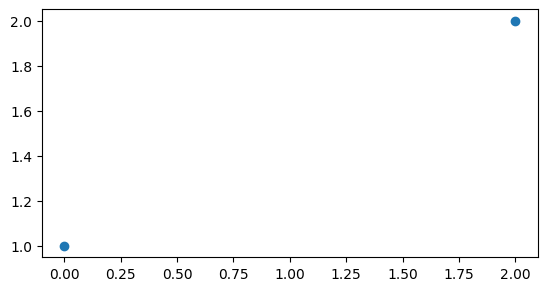

In [57]:
points_gdf.plot()

# Преобразования систем координат

Ответы на самые часто задаваемые вопросы про системы координат в ГИС https://gis-lab.info/qa/proj-sk-faq.html

Все основные системы координат есть в общем [реестре EPSG](https://epsg.io/)

Существует два основных типа систем координат, применяемых в ГИС и пространственном анализе:
1.   географические - в этих системах координаты определяются широтой и долготой на сфере/эллипсоиде;
2.   прямоугольные (иногда их как кальку с английского называют спроецированными) - в этих система координаты определяются в метрических единицах (метры, километры и т.д.) на плоскости.

Следует учитывать, что, если вы работаете с географическими системами координат, все измерения будут происходить в градусах и на сфере.
Если вы хотите измерять расстояния и площади на плоскости, то нужно использовать прямоугольные системы координат.


Для работы с метровым расстоянием рекомендуется использовать зональную систему координат **UTM**.
Кратко про эту систему координат можно почитать [здесь](https://ru.wikipedia.org/wiki/%D0%A3%D0%BD%D0%B8%D0%B2%D0%B5%D1%80%D1%81%D0%B0%D0%BB%D1%8C%D0%BD%D0%B0%D1%8F_%D0%BF%D0%BE%D0%BF%D0%B5%D1%80%D0%B5%D1%87%D0%BD%D0%B0%D1%8F_%D0%BF%D1%80%D0%BE%D0%B5%D0%BA%D1%86%D0%B8%D1%8F_%D0%9C%D0%B5%D1%80%D0%BA%D0%B0%D1%82%D0%BE%D1%80%D0%B0), а подробнее [здесь](https://www.gislounge.com/universal-transverse-mercator/).

Система координат **UTM (Universal Transverse Mercator )** представляет собой набор зональных систем координат.
Фактически UTM представляет собой набор из 60 отдельных «поперечных проекций Меркатора», покрывающих 60 продольных зон шириной 6° каждая. 
Он охватывает широты от 80 ° южной широты до 84 ° северной широты (полюса покрыты отдельной системой «UPS»). 
Эта система координат аналогична системе координат Гаусса-Крюгера, возможно знакомой вам, если вы изучали геодезию. Главное отличие между ними в том, как рассчитываются номера зон.

Для работы с системами координат существует библиотека [pyproj](https://pypi.org/project/pyproj/) 
Фактически эта библиотека является питоновским интерфейсом для взаимодействия с программой PROJ, которая используется во всех современных ГИС.

In [ ]:
# pip install pyproj

In [58]:
from pyproj import CRS

Систему координат можно задать несколькими способами: 
- просто по номеру из реестра, 
- по названию реестра и номеру системы координат в нем (единая строка),
- по строке в формате proj4,
- записав отдельно строками название реестра и номер системы координат в нем.

In [59]:
crs1 = CRS.from_epsg(4326)

crs2 = CRS.from_string('epsg:4326')

crs3 = CRS.from_proj4("+proj=latlon")

crs4 = CRS.from_user_input(('epsg', '4326'))

In [60]:
print(f'crs1: {crs1}\ncrs2: {crs2}\ncrs3: {crs3}\ncrs4: {crs4}')

crs1: EPSG:4326
crs2: epsg:4326
crs3: +proj=latlon +type=crs
crs4: epsg:4326


## Перепроецирование объектов `shapely`

Для перепроецирования и пересчета координат из одной системы в другую для таких объектов следует использовать так называемые объекты-трансформеры из пакета `pyproj`, создаваемые функцией `Transformer.from_crs`.
Эти объекты рассчитывают параметры перехода от одной системы координат к другой и хранят их в себе. 
Однако для создания трансформера нужно указать как исходную, так и целевую системы координат.

Перепроецируем одну из созданных нами ранее точек в систему координат **UTM**.
Для этого нужно сначала рассчитать необходимый номер зоны и определить номер системы координат в реестре.

In [118]:
import math

In [61]:
def get_utm_zone(lon, lat):
    zone = int((lon + 180) / 6) + 1
    return f'EPSG:326{zone}' if lat >= 0 else f'EPSG:327{zone}'


In [69]:
get_utm_zone(lon=pin_itmo.y , lat=pin_itmo.x)

'EPSG:326417968'

In [121]:
crs_itmo = CRS.from_epsg(32636)

Далее создадим объект трансформер.

In [122]:
from pyproj import Transformer

In [123]:
transformer = Transformer.from_crs(CRS.from_string("epsg:4326"), crs_itmo)

transformer

<Conversion Transformer: pipeline>
Description: UTM zone 36N
Area of Use:
- name: Between 30°E and 36°E, northern hemisphere between equator and 84°N, onshore and offshore.
- bounds: (30.0, 0.0, 36.0, 84.0)

Рассчитаем новые координаты точки

In [124]:
coords_utm_itmo = transformer.transform(pin_itmo.x, pin_itmo.y )
print(f'coords_utm_itmo: {coords_utm_itmo}. Тип объекта: {type(coords_utm_itmo)}')

coords_utm_itmo: (347235.4179799134, 6648363.905023121). Тип объекта: <class 'tuple'>


В результате мы получили кортеж с координатами нашей точки, из которого уже можно создать пространственный объект.

In [125]:
pin_itmo_utm = Point(coords_utm_itmo)

pin_itmo_utm.xy

(array('d', [347235.4179799134]), array('d', [6648363.905023121]))

## Перепроецирование объектов `GeoDataFrame`

У объектов `GeoDataFrame` система координат является свойством самих объектов, как было уже показано выше.

In [63]:
guerry.crs

<Projected CRS: EPSG:27572>
Name: NTF (Paris) / Lambert zone II
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: France mainland onshore between 50.5 grads and 53.5 grads North (45°27'N to 48°09'N). Also used over all onshore mainland France.
- bounds: (-4.87, 42.33, 8.23, 51.14)
Coordinate Operation:
- name: Lambert zone II
- method: Lambert Conic Conformal (1SP)
Datum: Nouvelle Triangulation Francaise (Paris)
- Ellipsoid: Clarke 1880 (IGN)
- Prime Meridian: Paris

Мы можем *назначить* новую систему координат, используя метод `.set_crs`.
Если у объекта уже есть система координат, тогда нужно использовать параметр `allow_override=True`, который позволить принудительно назначить новую систему координат. Если эту опцию не использовать в нашем случае мы получим ошибку.

In [70]:
guerry.set_crs(4326)

ValueError: The GeoSeries already has a CRS which is not equal to the passed CRS. Specify 'allow_override=True' to allow replacing the existing CRS without doing any transformation. If you actually want to transform the geometries, use 'GeoSeries.to_crs' instead.

In [71]:
guerry.set_crs(4326, allow_override=True)

,dept,Region,Dprtmnt,Crm_prs,Crm_prp,Litercy,Donatns,Infants,Suicids,MainCty,...,Infntcd,Dntn_cl,Lottery,Desertn,Instrct,Prsttts,Distanc,Area,Pop1831,geometry
0,1.0,S,Ain,28870.0,15890.0,37.0,5098.0,33120.0,35039.0,2.0,...,60.0,69.0,41.0,55.0,46.0,13.0,218.372,5762.0,346.03,"POLYGON ((801150 2092615, 800669 2093190, 8006..."
1,2.0,S,Aisne,26226.0,5521.0,51.0,8901.0,14572.0,12831.0,2.0,...,82.0,36.0,38.0,82.0,24.0,327.0,65.945,7369.0,513.00,"POLYGON ((729326 2521619, 729320 2521230, 7292..."
2,3.0,S,Allier,26747.0,7925.0,13.0,10973.0,17044.0,114121.0,2.0,...,42.0,76.0,66.0,16.0,85.0,34.0,161.927,7340.0,298.26,"POLYGON ((710830 2137350, 711746 2136617, 7124..."
3,4.0,S,Basses-Alpes,12935.0,7289.0,46.0,2733.0,23018.0,14238.0,1.0,...,12.0,37.0,80.0,32.0,29.0,2.0,351.399,6925.0,155.90,"POLYGON ((882701 1920024, 882408 1920733, 8817..."
4,5.0,S,Hautes-Alpes,17488.0,8174.0,69.0,6962.0,23076.0,16171.0,1.0,...,23.0,64.0,79.0,35.0,7.0,1.0,320.280,5549.0,129.10,"POLYGON ((886504 1922890, 885733 1922978, 8854..."
5,7.0,S,Ardeche,9474.0,10263.0,27.0,3188.0,42117.0,52547.0,1.0,...,47.0,67.0,70.0,19.0,62.0,1.0,279.413,5529.0,340.73,"POLYGON ((747008 1925789, 746630 1925762, 7457..."
6,8.0,S,Ardennes,35203.0,8847.0,67.0,6400.0,16106.0,26198.0,2.0,...,85.0,49.0,31.0,62.0,9.0,83.0,105.694,5229.0,289.62,"POLYGON ((818893 2514767, 818614 2514515, 8179..."
7,9.0,S,Ariege,6173.0,9597.0,18.0,3542.0,22916.0,123625.0,1.0,...,28.0,63.0,75.0,22.0,77.0,3.0,385.313,4890.0,253.12,"POLYGON ((509103 1747787, 508820 1747513, 5081..."
8,10.0,S,Aube,19602.0,4086.0,59.0,3608.0,18642.0,10989.0,2.0,...,54.0,9.0,28.0,86.0,15.0,207.0,83.244,6004.0,246.36,"POLYGON ((775400 2345600, 775068 2345397, 7735..."
9,11.0,S,Aude,15647.0,10431.0,34.0,2582.0,20225.0,66498.0,2.0,...,35.0,27.0,50.0,63.0,48.0,1.0,370.949,6139.0,270.13,"POLYGON ((626230 1810121, 626269 1810496, 6274..."


> **NB** такое назначение системы координат не влечет за собой их пересчет, они в этом случае остаются неизменными

> Метод `set_crs` предназначен только для назначения системы координат тем объектам, в которых ее нет или она неверна.

> **NB!!!** не является перепроецированием 

In [72]:
guerry.set_crs(27572, allow_override=True)

,dept,Region,Dprtmnt,Crm_prs,Crm_prp,Litercy,Donatns,Infants,Suicids,MainCty,...,Infntcd,Dntn_cl,Lottery,Desertn,Instrct,Prsttts,Distanc,Area,Pop1831,geometry
0,1.0,S,Ain,28870.0,15890.0,37.0,5098.0,33120.0,35039.0,2.0,...,60.0,69.0,41.0,55.0,46.0,13.0,218.372,5762.0,346.03,"POLYGON ((801150 2092615, 800669 2093190, 8006..."
1,2.0,S,Aisne,26226.0,5521.0,51.0,8901.0,14572.0,12831.0,2.0,...,82.0,36.0,38.0,82.0,24.0,327.0,65.945,7369.0,513.00,"POLYGON ((729326 2521619, 729320 2521230, 7292..."
2,3.0,S,Allier,26747.0,7925.0,13.0,10973.0,17044.0,114121.0,2.0,...,42.0,76.0,66.0,16.0,85.0,34.0,161.927,7340.0,298.26,"POLYGON ((710830 2137350, 711746 2136617, 7124..."
3,4.0,S,Basses-Alpes,12935.0,7289.0,46.0,2733.0,23018.0,14238.0,1.0,...,12.0,37.0,80.0,32.0,29.0,2.0,351.399,6925.0,155.90,"POLYGON ((882701 1920024, 882408 1920733, 8817..."
4,5.0,S,Hautes-Alpes,17488.0,8174.0,69.0,6962.0,23076.0,16171.0,1.0,...,23.0,64.0,79.0,35.0,7.0,1.0,320.280,5549.0,129.10,"POLYGON ((886504 1922890, 885733 1922978, 8854..."
5,7.0,S,Ardeche,9474.0,10263.0,27.0,3188.0,42117.0,52547.0,1.0,...,47.0,67.0,70.0,19.0,62.0,1.0,279.413,5529.0,340.73,"POLYGON ((747008 1925789, 746630 1925762, 7457..."
6,8.0,S,Ardennes,35203.0,8847.0,67.0,6400.0,16106.0,26198.0,2.0,...,85.0,49.0,31.0,62.0,9.0,83.0,105.694,5229.0,289.62,"POLYGON ((818893 2514767, 818614 2514515, 8179..."
7,9.0,S,Ariege,6173.0,9597.0,18.0,3542.0,22916.0,123625.0,1.0,...,28.0,63.0,75.0,22.0,77.0,3.0,385.313,4890.0,253.12,"POLYGON ((509103 1747787, 508820 1747513, 5081..."
8,10.0,S,Aube,19602.0,4086.0,59.0,3608.0,18642.0,10989.0,2.0,...,54.0,9.0,28.0,86.0,15.0,207.0,83.244,6004.0,246.36,"POLYGON ((775400 2345600, 775068 2345397, 7735..."
9,11.0,S,Aude,15647.0,10431.0,34.0,2582.0,20225.0,66498.0,2.0,...,35.0,27.0,50.0,63.0,48.0,1.0,370.949,6139.0,270.13,"POLYGON ((626230 1810121, 626269 1810496, 6274..."


Для перепроецирования объектов существует метод `to_crs`.

In [75]:
guerry_wgs = guerry.to_crs(4326)

guerry_wgs.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [76]:
guerry_wgs.head()

,dept,Region,Dprtmnt,Crm_prs,Crm_prp,Litercy,Donatns,Infants,Suicids,MainCty,...,Infntcd,Dntn_cl,Lottery,Desertn,Instrct,Prsttts,Distanc,Area,Pop1831,geometry
0,1.0,S,Ain,28870.0,15890.0,37.0,5098.0,33120.0,35039.0,2.0,...,60.0,69.0,41.0,55.0,46.0,13.0,218.372,5762.0,346.03,"POLYGON ((4.92452 45.80404, 4.91858 45.80935, ..."
1,2.0,S,Aisne,26226.0,5521.0,51.0,8901.0,14572.0,12831.0,2.0,...,82.0,36.0,38.0,82.0,24.0,327.0,65.945,7369.0,513.00,"POLYGON ((4.12644 49.67821, 4.12624 49.67472, ..."
2,3.0,S,Allier,26747.0,7925.0,13.0,10973.0,17044.0,114121.0,2.0,...,42.0,76.0,66.0,16.0,85.0,34.0,161.927,7340.0,298.26,"POLYGON ((3.77335 46.22719, 3.78505 46.22045, ..."
3,4.0,S,Basses-Alpes,12935.0,7289.0,46.0,2733.0,23018.0,14238.0,1.0,...,12.0,37.0,80.0,32.0,29.0,2.0,351.399,6925.0,155.90,"POLYGON ((5.87269 44.22421, 5.86943 44.2307, 5..."
4,5.0,S,Hautes-Alpes,17488.0,8174.0,69.0,6962.0,23076.0,16171.0,1.0,...,23.0,64.0,79.0,35.0,7.0,1.0,320.280,5549.0,129.10,"POLYGON ((5.92183 44.24841, 5.91224 44.24951, ..."


> **NB** Перепроецирование и пересчет координат осуществляются методом `.to_crs`

# Операции с пространственными объектами типа `GeoDataFrame`


## Расчет геометрических параметров объектов

Аналогично объектам `shapely` мы можем использовать методы объектов для вычисления расстояния, периметра и площади объектов.

| **Метод** 	| **shapely** 	| **geopandas** 	|                                                 	|
|-----------	|-------------	|---------------	|-------------------------------------------------	|
| .length   	|    Length   	|     Length    	| Длина линейного объекта или периметр площадного 	|
| .area     	|    Area     	|      Area     	| Площадь                                         	|
| .distance 	|   Distance  	|    Distance   	| Расстояние                                      	|


> **NB** помните, что все вычисления осуществляются единицах системы координат вашего объекта.


In [67]:
guerry.area

0     5.784328e+09
1     7.435863e+09
2     7.378633e+09
3     7.009832e+09
4     5.696593e+09
5     5.570000e+09
6     5.255254e+09
7     4.927863e+09
8     6.028654e+09
9     6.370164e+09
10    8.787689e+09
11    5.105167e+09
12    5.613253e+09
13    5.779975e+09
14    5.974584e+09
15    6.914309e+09
16    7.307826e+09
17    5.902357e+09
18    8.799459e+09
19    6.984510e+09
20    5.598373e+09
21    9.229190e+09
22    5.253258e+09
23    6.564463e+09
24    6.043508e+09
25    5.936494e+09
26    6.745738e+09
27    5.888648e+09
28    6.379883e+09
29    6.318447e+09
30    1.016175e+10
31    6.248432e+09
32    6.845077e+09
33    6.896581e+09
34    6.158313e+09
35    7.879230e+09
36    5.049716e+09
37    9.371348e+09
38    6.418670e+09
39    4.806874e+09
40    5.008877e+09
41    6.908492e+09
42    6.815491e+09
43    5.233360e+09
44    5.394544e+09
45    5.181948e+09
46    7.230561e+09
47    6.011881e+09
48    8.199175e+09
49    6.260489e+09
50    5.213995e+09
51    5.287834e+09
52    6.2441

> **NB** все вычисления в `geopandas` планарны, то есть осуществляются на плоскости, поэтому, если вы хотите получать адекватные результаты, сначала объект нужно перепроецировать в прямоугольную систему координат

При вычислении расстояний, они могут быть рассчитаны как между всеми возможными парами объектов внутри `GeoDataFrame`, так и между каким-то конкретным объектом и прочими.

In [80]:
get_utm_zone(lon=guerry_wgs.centroid[1].y , lat=guerry_wgs.centroid[1].x)

/var/folders/j9/9s_tg9t546d4q617w79_f05r0000gn/T/ipykernel_46626/3638807373.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  get_utm_zone(lon=guerry_wgs.centroid[1].y , lat=guerry_wgs.centroid[1].x)


'EPSG:32639'

In [81]:
guerry_utm = guerry_wgs.to_crs(32639)

In [82]:
guerry.area

0     5.784328e+09
1     7.435863e+09
2     7.378633e+09
3     7.009832e+09
4     5.696593e+09
5     5.570000e+09
6     5.255254e+09
7     4.927863e+09
8     6.028654e+09
9     6.370164e+09
10    8.787689e+09
11    5.105167e+09
12    5.613253e+09
13    5.779975e+09
14    5.974584e+09
15    6.914309e+09
16    7.307826e+09
17    5.902357e+09
18    8.799459e+09
19    6.984510e+09
20    5.598373e+09
21    9.229190e+09
22    5.253258e+09
23    6.564463e+09
24    6.043508e+09
25    5.936494e+09
26    6.745738e+09
27    5.888648e+09
28    6.379883e+09
29    6.318447e+09
30    1.016175e+10
31    6.248432e+09
32    6.845077e+09
33    6.896581e+09
34    6.158313e+09
35    7.879230e+09
36    5.049716e+09
37    9.371348e+09
38    6.418670e+09
39    4.806874e+09
40    5.008877e+09
41    6.908492e+09
42    6.815491e+09
43    5.233360e+09
44    5.394544e+09
45    5.181948e+09
46    7.230561e+09
47    6.011881e+09
48    8.199175e+09
49    6.260489e+09
50    5.213995e+09
51    5.287834e+09
52    6.2441

In [84]:
guerry_utm.geometry.distance

<bound method GeoPandasBase.distance of 0     POLYGON ((-3026192.3 6209436.047, -3026212.433...
1     POLYGON ((-2776997.002 6640510.345, -2777288.1...
2     POLYGON ((-3075229.75 6315383.997, -3074940.04...
3     POLYGON ((-3075199.688 5993912.849, -3074966.8...
4     POLYGON ((-3069679.173 5993852.909, -3070324.7...
5     POLYGON ((-3195959.572 6096202.908, -3196327.6...
6     POLYGON ((-2704824.954 6569151.284, -2705248.3...
7     POLYGON ((-3548737.888 6103647.927, -3549209.7...
8     POLYGON ((-2865745.841 6453586.868, -2866185.5...
9     POLYGON ((-3392297.056 6076304.728, -3391986.4...
10    POLYGON ((-3253639.983 6220191.013, -3254087.6...
11    POLYGON ((-3167125.759 5985163.426, -3166603.0...
12    POLYGON ((-3179528.078 6850745.081, -3179433.8...
13    POLYGON ((-3271455.556 6294545.399, -3271158.0...
14    POLYGON ((-3318369.669 6489155.883, -3318299.7...
15    MULTIPOLYGON (((-3436753.363 6585630.06, -3436...
16    POLYGON ((-3113561.52 6521197.762, -3113010.52...
17    PO

А в этом случае расстояние будет рассчитываться от первого объекта до всех остальных.

In [83]:
guerry_utm.distance(guerry_wgs["geometry"].iloc[0])

0     6.835347e+06
1     7.185473e+06
2     7.006666e+06
3     6.629416e+06
4     6.667971e+06
5     6.840835e+06
6     7.103103e+06
7     6.971221e+06
8     7.051614e+06
9     6.900995e+06
10    6.928219e+06
11    6.688893e+06
12    7.436426e+06
13    6.987809e+06
14    7.244042e+06
15    7.286047e+06
16    7.115173e+06
17    7.080694e+06
18    6.947727e+06
19    7.596212e+06
20    7.102264e+06
21    7.147035e+06
22    6.838789e+06
23    6.748002e+06
24    7.346251e+06
25    7.274534e+06
26    7.698620e+06
27    6.808388e+06
28    7.021167e+06
29    7.103772e+06
30    7.241625e+06
31    6.843918e+06
32    7.505692e+06
33    7.165567e+06
34    7.267687e+06
35    6.736013e+06
36    6.855229e+06
37    7.222025e+06
38    7.212337e+06
39    6.895408e+06
40    6.905480e+06
41    7.469886e+06
42    7.162887e+06
43    7.066723e+06
44    7.155093e+06
45    6.891772e+06
46    7.377343e+06
47    7.512200e+06
48    7.074754e+06
49    6.960997e+06
50    7.441911e+06
51    6.910504e+06
52    7.0067

Полученные результаты не обязательно должны сохраняться в новый объект, мы можем создать новую колонку в `GeoDataFrame` и записать результат в нее.

In [86]:
guerry_utm["distance"] = guerry_utm.distance(guerry_utm["geometry"].iloc[0])

guerry_utm.head()

,dept,Region,Dprtmnt,Crm_prs,Crm_prp,Litercy,Donatns,Infants,Suicids,MainCty,...,Dntn_cl,Lottery,Desertn,Instrct,Prsttts,Distanc,Area,Pop1831,geometry,distance
0,1.0,S,Ain,28870.0,15890.0,37.0,5098.0,33120.0,35039.0,2.0,...,69.0,41.0,55.0,46.0,13.0,218.372,5762.0,346.03,"POLYGON ((-3026192.3 6209436.047, -3026212.433...",0.000000
1,2.0,S,Aisne,26226.0,5521.0,51.0,8901.0,14572.0,12831.0,2.0,...,36.0,38.0,82.0,24.0,327.0,65.945,7369.0,513.00,"POLYGON ((-2776997.002 6640510.345, -2777288.1...",322581.635556
2,3.0,S,Allier,26747.0,7925.0,13.0,10973.0,17044.0,114121.0,2.0,...,76.0,66.0,16.0,85.0,34.0,161.927,7340.0,298.26,"POLYGON ((-3075229.75 6315383.997, -3074940.04...",71383.293810
3,4.0,S,Basses-Alpes,12935.0,7289.0,46.0,2733.0,23018.0,14238.0,1.0,...,37.0,80.0,32.0,29.0,2.0,351.399,6925.0,155.90,"POLYGON ((-3075199.688 5993912.849, -3074966.8...",151364.819076
4,5.0,S,Hautes-Alpes,17488.0,8174.0,69.0,6962.0,23076.0,16171.0,1.0,...,64.0,79.0,35.0,7.0,1.0,320.280,5549.0,129.10,"POLYGON ((-3069679.173 5993852.909, -3070324.7...",83906.586121


## Создание новых объектов на основе имеющихся

Для создания новых объектов с использованием уже имеющихся также могут использоваться методы, реализованные для объектов `GeoDataFrame`.

| **Метод**                                    | **shapely**  	| **geopandas**             	|                              	|
|----------------------------------------------|--------------	|---------------------------	|-----------------------------	|
| `.centroid`                                  |   Centroids  	|         Centroids         	| Центроид (геометрический центр объекта)|
| `.buffer`                                    |    Buffers   	|          Buffers          	| Буферные зоны                 |
| `.intersection / .overlay (..., how="intersection")` 	| Intersection 	| Set operations (.overlay) 	| Пересечение           |
| `.union / .overlay (..., how="union")`               	|     Union    	| Set operations (.overlay) 	| Объединение                             	|
| `.difference / .overlay(..., how="difference")`      	|  Difference  	| Set operations (.overlay) 	| Разность                                	|

> Обратите внимание, что операции между парами объектов в `geopandas` реализованы через один метод `.overlay`, в котором нужно указывать, какого вида операцию вы осуществляете.

> в `shapely` эти операции же реализованы различными методами.

In [87]:
ctr = guerry.centroid

In [88]:
ctr

0     POINT (832852.279 2126600.576)
1     POINT (688485.627 2507622.044)
2     POINT (665510.138 2155203.452)
3     POINT (912995.751 1908303.142)
4     POINT (911433.897 1970311.894)
5      POINT (765421.342 1974521.21)
6     POINT (766676.638 2515626.684)
7     POINT (531866.418 1769020.126)
8      POINT (735432.699 2368846.89)
9     POINT (606309.985 1788959.109)
10    POINT (627416.659 1919941.034)
11    POINT (822471.117 1842079.559)
12    POINT (402723.656 2459126.284)
13    POINT (626174.212 2005646.903)
14    POINT (433800.194 2082007.626)
15    POINT (365909.867 2091205.198)
16    POINT (611728.939 2229456.227)
17    POINT (563991.198 2039719.576)
18     POINT (783740.64 2272308.158)
19    POINT (215377.395 2395187.094)
20     POINT (575426.97 2121172.922)
21    POINT (474413.294 2012783.542)
22    POINT (905029.178 2248422.693)
23    POINT (824554.192 1968848.768)
24    POINT (502094.781 2458132.967)
25    POINT (528405.557 2376945.354)
26    POINT (125581.685 2381812.622)
2

<Axes: >

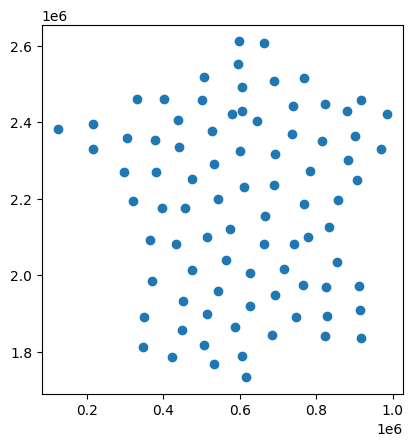

In [89]:
ctr.plot()

In [96]:
buffers = ctr.buffer(10000)

buffers

0     POLYGON ((842852.279 2126600.576, 842804.126 2...
1     POLYGON ((698485.627 2507622.044, 698437.475 2...
2     POLYGON ((675510.138 2155203.452, 675461.986 2...
3     POLYGON ((922995.751 1908303.142, 922947.598 1...
4     POLYGON ((921433.897 1970311.894, 921385.745 1...
5     POLYGON ((775421.342 1974521.21, 775373.189 19...
6     POLYGON ((776676.638 2515626.684, 776628.486 2...
7     POLYGON ((541866.418 1769020.126, 541818.265 1...
8     POLYGON ((745432.699 2368846.89, 745384.546 23...
9     POLYGON ((616309.985 1788959.109, 616261.832 1...
10    POLYGON ((637416.659 1919941.034, 637368.507 1...
11    POLYGON ((832471.117 1842079.559, 832422.964 1...
12    POLYGON ((412723.656 2459126.284, 412675.503 2...
13    POLYGON ((636174.212 2005646.903, 636126.059 2...
14    POLYGON ((443800.194 2082007.626, 443752.041 2...
15    POLYGON ((375909.867 2091205.198, 375861.714 2...
16    POLYGON ((621728.939 2229456.227, 621680.786 2...
17    POLYGON ((573991.198 2039719.576, 573943.0

<Axes: >

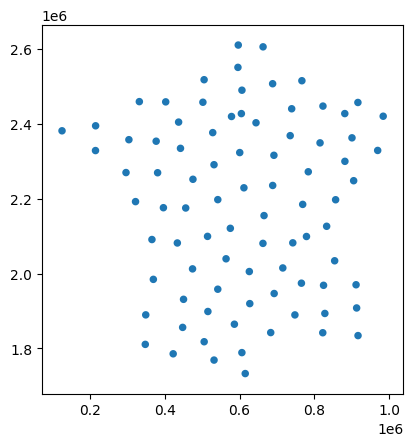

In [97]:
buffers.plot()